# Step Metric Plots

Use one row per step: the row with the smallest guidance value for that step.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="deep",
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "legend.frameon": False,
    },
)

repo_root = Path.cwd()
if not (repo_root / "checkpoints").exists():
    repo_root = repo_root.parent

summary_path = repo_root / "checkpoints/test_samples/sweeps/ckpt82753_20260410/ckpt82753_20260410_pseudobulk_metrics_summary.csv"
plot_dir = repo_root / "analyze/step_metric_plots"
plot_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(summary_path)
df[["steps", "guidance"]] = df[["steps", "guidance"]].apply(pd.to_numeric, errors="coerce")
metric_cols = [
    "overall_r2_mean",
    "delta_r2_mean",
    "pdcorr_mean",
    "delta_pert_r",
    "mae_mean",
    "Overall_MMD",
    "Delta_MMD",
]
df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors="coerce")
df.head()

,sweep,steps,guidance,num_conditions,group_cols,overall_r2_mean,delta_r2_mean,pdcorr_mean,delta_pert_r,mae_mean,Overall_MMD,Delta_MMD,true_path,pred_path,pert_col,control_label,match_control_cols
0,s1_g0,1,0.00,380,['gene'],0.984484,0.518995,0.751574,0.464097,0.046507,0.035602,0.011631,/home/zichong/fork/PerturbDiff/checkpoints/tes...,/home/zichong/fork/PerturbDiff/checkpoints/tes...,gene,non-targeting,"['cell_line', 'gem_group']"
1,s2_g0.25,2,0.25,380,['gene'],0.983599,0.482411,0.742788,0.465993,0.047557,0.032206,0.011405,/home/zichong/fork/PerturbDiff/checkpoints/tes...,/home/zichong/fork/PerturbDiff/checkpoints/tes...,gene,non-targeting,"['cell_line', 'gem_group']"
2,s2_g0.50,2,0.50,380,['gene'],0.982456,0.442802,0.733188,0.464447,0.048876,0.032998,0.011812,/home/zichong/fork/PerturbDiff/checkpoints/tes...,/home/zichong/fork/PerturbDiff/checkpoints/tes...,gene,non-targeting,"['cell_line', 'gem_group']"
3,s2_g0.75,2,0.75,380,['gene'],0.981030,0.397920,0.722220,0.460230,0.050457,0.033938,0.012313,/home/zichong/fork/PerturbDiff/checkpoints/tes...,/home/zichong/fork/PerturbDiff/checkpoints/tes...,gene,non-targeting,"['cell_line', 'gem_group']"
4,s2_g1.00,2,1.00,380,['gene'],0.979369,0.349500,0.710742,0.453799,0.052218,0.034991,0.012893,/home/zichong/fork/PerturbDiff/checkpoints/tes...,/home/zichong/fork/PerturbDiff/checkpoints/tes...,gene,non-targeting,"['cell_line', 'gem_group']"


In [6]:
plot_df = (
    df.dropna(subset=["steps", "guidance"])
    .sort_values(["steps", "guidance", "sweep"])
    .loc[lambda x: x.groupby("steps")["guidance"].idxmin()]
    .sort_values("steps")
    .reset_index(drop=True)
)

plot_df[["sweep", "steps", "guidance"] + metric_cols]

,sweep,steps,guidance,overall_r2_mean,delta_r2_mean,pdcorr_mean,delta_pert_r,mae_mean,Overall_MMD,Delta_MMD
0,s1_g0,1,0.00,0.984484,0.518995,0.751574,0.464097,0.046507,0.035602,0.011631
1,s2_g0.25,2,0.25,0.983599,0.482411,0.742788,0.465993,0.047557,0.032206,0.011405
2,s3_g0.25,3,0.25,0.983522,0.479095,0.739737,0.460810,0.047897,0.027620,0.010755
3,s4_g0.25,4,0.25,0.983185,0.467526,0.733845,0.456400,0.048554,0.025040,0.010429
4,s5_g0.25,5,0.25,0.982470,0.442122,0.722814,0.449228,0.049741,0.022936,0.010246
5,s6_g0.25,6,0.25,0.981891,0.420475,0.713924,0.444311,0.050674,0.021832,0.010188
6,s8_g0.25,8,0.25,0.980784,0.380982,0.698814,0.436728,0.052355,0.021183,0.010332
7,s10_g0.25,10,0.25,0.979713,0.341224,0.685342,0.430611,0.053914,0.021266,0.010601
8,s15_g0.25,15,0.25,0.977905,0.275091,0.664511,0.420371,0.056423,0.022018,0.011184
9,s20_g0.25,20,0.25,0.976718,0.233026,0.651813,0.413906,0.058019,0.022879,0.011653


In [7]:
def plot_metrics(metrics, title, ylabel, filename, y_limits=None):
    long_df = plot_df.melt(
        id_vars=["steps", "guidance", "sweep"],
        value_vars=metrics,
        var_name="metric",
        value_name="value",
    )

    fig, ax = plt.subplots(figsize=(9.8, 5.4))
    sns.lineplot(
        data=long_df,
        x="steps",
        y="value",
        hue="metric",
        style="metric",
        markers=True,
        dashes=False,
        linewidth=2.4,
        markersize=8,
        ax=ax,
    )
    ax.set_title(title, pad=12)
    ax.set_xlabel("Flow steps (log scale)")
    ax.set_ylabel(ylabel)
    steps = plot_df["steps"].tolist()
    ax.set_xscale("log", base=2)
    ax.set_xticks(steps)
    ax.set_xticklabels([str(int(step)) for step in steps], ha="right")
    if y_limits is not None:
        ax.set_ylim(*y_limits)
    ax.legend(title=None, loc="best")
    sns.despine(ax=ax)
    fig.tight_layout()
    fig.savefig(plot_dir / filename, bbox_inches="tight")
    return fig, ax

Saved figures to: /home/zichong/fork/PerturbDiff/analyze/step_metric_plots


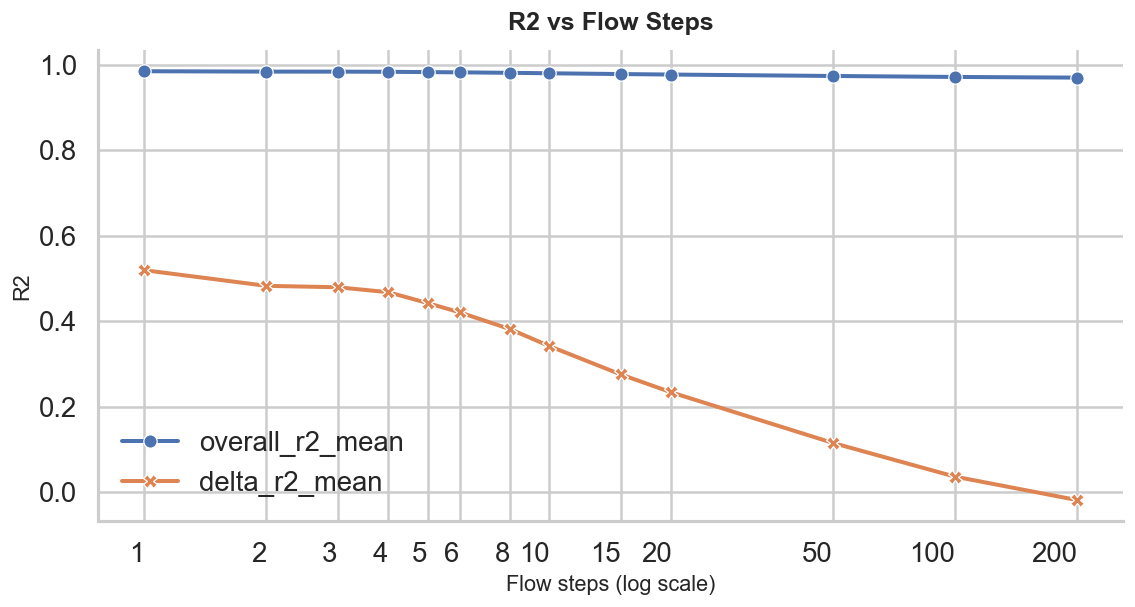

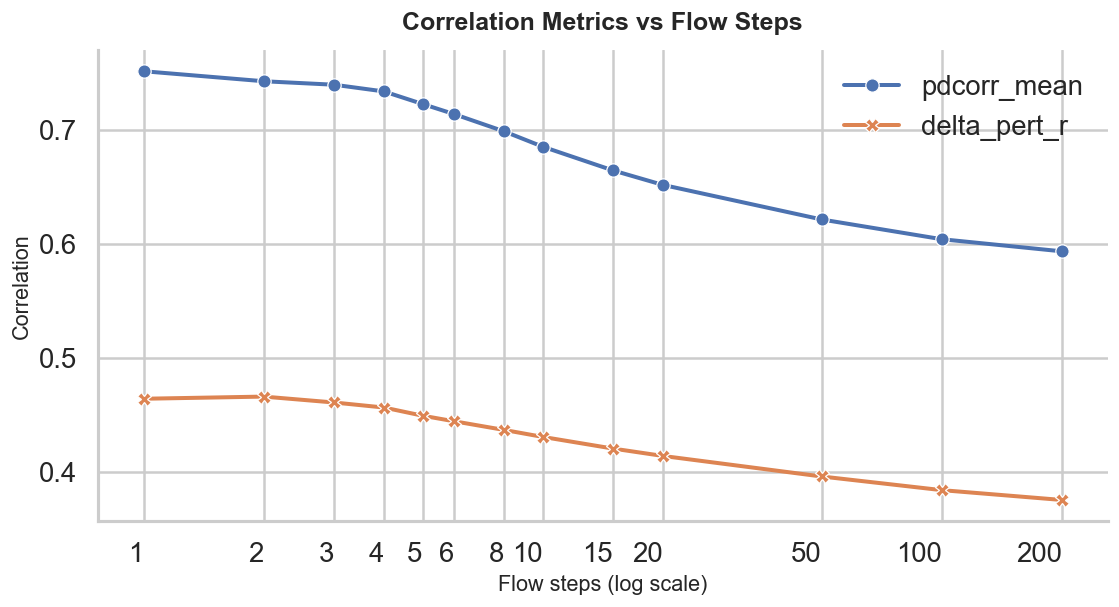

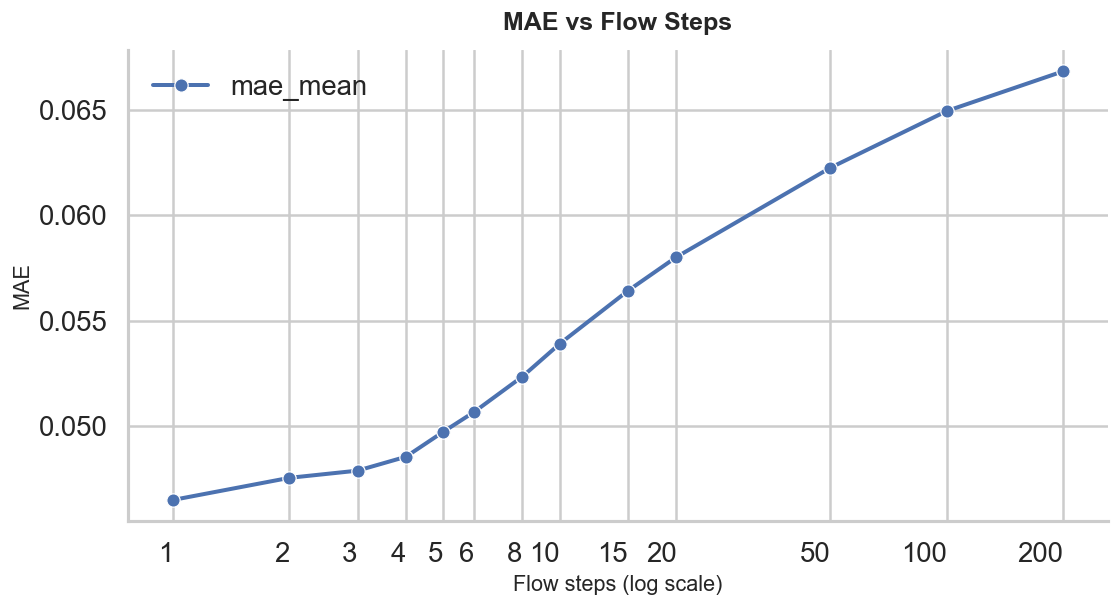

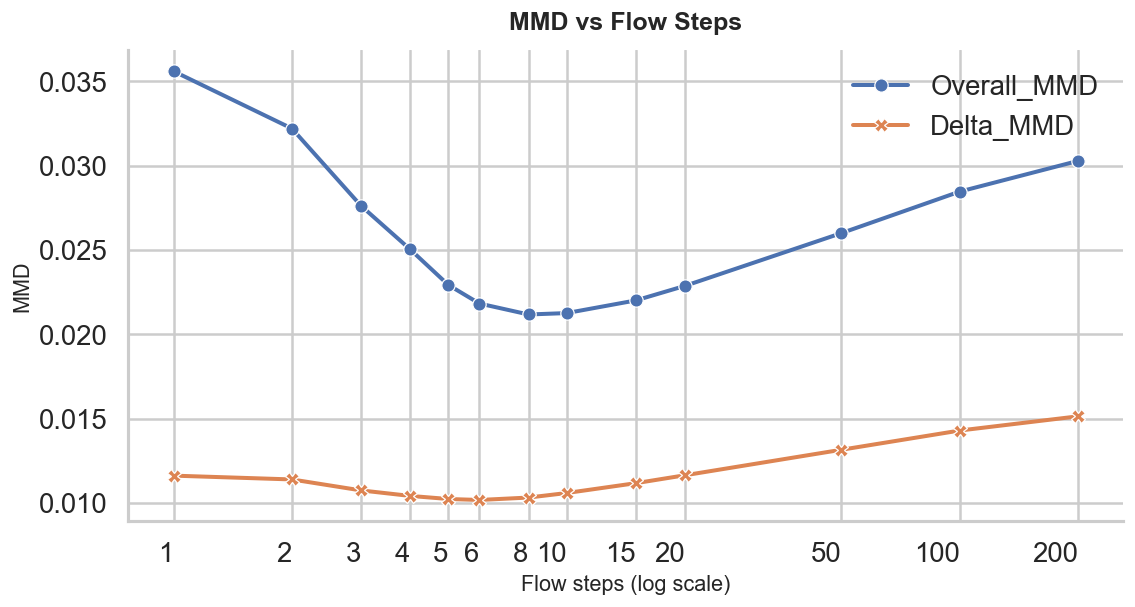

In [8]:
plot_metrics(
    ["overall_r2_mean", "delta_r2_mean"],
    "R2 vs Flow Steps",
    "R2",
    "r2_vs_steps.png",
)

plot_metrics(
    ["pdcorr_mean", "delta_pert_r"],
    "Correlation Metrics vs Flow Steps",
    "Correlation",
    "correlation_vs_steps.png",
)

plot_metrics(
    ["mae_mean"],
    "MAE vs Flow Steps",
    "MAE",
    "mae_vs_steps.png",
)

plot_metrics(
    ["Overall_MMD", "Delta_MMD"],
    "MMD vs Flow Steps",
    "MMD",
    "mmd_vs_steps.png",
)

print(f"Saved figures to: {plot_dir}")